In [1]:
import numpy as np
import matplotlib.pyplot as plt

from utils import load_config
from Langevin import Langevin_sim
from geometry import make_geometry_mask

In [2]:
# Approximation of f2-f1
def f(x):
    return 0.3*np.sin(x)  # f2-f1 #TODO implement better approximation or original functions
                          # 0.3 comes from f2-f1 approximation

# Light intensity field
def I(r): # r - positions to check field at:
    return np.ones((1, r.shape[1]), dtype=float)   # has to return shape (1, r.shape[1]), r.shape[1] = N

f_fn = f
I_fn = I

In [3]:
config = load_config("config_free")

In [4]:
# Geometry

z_min = 0.
z_max = 10.
R = 100.

phi_rand = 2*np.pi*np.random.rand(config["N"])
radius_rand = R*np.random.rand(config["N"])
z_rand = z_min + (z_max-z_min)*np.random.rand(config["N"])

# Mask to be passed to Langevin_sim for implementing BC
mask_fn = make_geometry_mask("cylinder", R=R, z_min=z_min, z_max=z_max)


# Initial condition from within the cylinder
x = radius_rand*np.cos(phi_rand)
y = radius_rand*np.sin(phi_rand)
z = z_rand
r_init = np.concatenate((x,y,z))
r_init = r_init.reshape((config["dim"],config["N"]))

In [5]:
# TODO build mask callable into Langevin_sim and implement BC

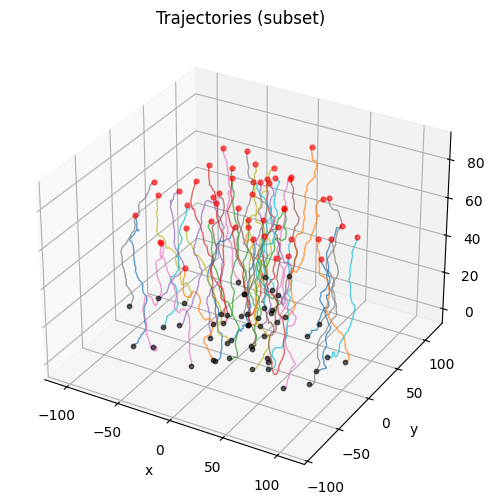

(<Figure size 700x600 with 1 Axes>,
 <Axes3D: title={'center': 'Trajectories (subset)'}, xlabel='x', ylabel='y', zlabel='z'>)

In [6]:
sim = Langevin_sim(config,I_fn=I_fn, f_fn=f_fn, r0=r_init)
results = sim.run()
sim.plot_trajectories()